# 

# Coherence due to the small separation

In {numref}`sec:openqm-qme-method` it is shown that $\Gamma_{12}$ is a key parameter to control coherence=y between $|eg\rangel$ and $|ge\rangle$. As $r_{12} \rightarrow 0$, $\Gamma_{12}$ approaches $\gamma_0$ where the coherency is perfect.  In the opposite limit $Gamma_{12}$ vanishes and coherency is completely lost.  Actually, we haven't confirmed it yet.  The following code compute the off-diagonal element $\rho_{eg,ge}$ of the steady state, normalized by $\rho_{eg,eg}$,  as a function of $r_{12}/\lambda_{0}$.  Recall that $r_{12}/\lambda_{0} = 10^{-3} \sim 1$ for a typical quantum dots.  The plot clearly shows that the off-diagonal element neatly vanishes at $r_{12}/\lambda_{0} = 0.2$, validating the result of {numref}`ch:dimer-case1`.

```{admonition}  **QuTiP Note**
:class: note
:name: note:off-diagonal-dissipator

When a dissipator has no off-diagonal term, you need only a system Hamiltonian (`H`) and collapes operators (`c_ops`). We can just plug them into various routines like `steadystate(H,c_ops)`.  However, that method does not work when off-diagonal terms are present.  There are two ways to deal with the off-diagonal terms.

 1. Diagonalize the dissipator and use the collapse operators corresponding to the eigen vectors.
 2. Construct a Liouvillian superoperator (`L`) using function `lindblad_dissipator()`.   Most of routines accept the Liouvillean superoperator in place of `H, c_ops`.
    For jump operators `a` and `b`,
    * digonal dissipator:  `D1 = lindblad_dissipator(a) + lindblad_dissipator(b)`  
      or `D1 = lindblad_dissipator(a,a) + lindblad_dissipator(b,b)`
    * off-diagonal dissipator: D2 = `lindblad_dissipator(a,b) + lindblad_dissipator(b,a)`
    * Liouville super operator: L = `liouvillian(H) + D1 + D2
    * See the [documentation](https://qutip.readthedocs.io/en/qutip-5.3.x/apidoc/quantumobject.html#module-qutip.core.superoperator)

Note that a Hamiltonian $H$ is a regular operator and a Liouvillian $\mathcal{L}$ is a super operator.  In order to add $H$ to $\mathcal{L}$, you must convert $H$ to a super operator $-i [H, \cdot]$ using function `liouvillian(H)`. See the following example.
```

In [1]:
# This code block defines functions to be used in the later code
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())] 

# Define the Hamiltonian with dipole-dipole coupling
def system_hamiltonian(omega0,omega12):
  
    H = 0.5*omega0*(sz[0]+sz[1])
    H += omega12*(sp[0]*sm[1]+sp[1]*sm[0])
    return H

# Define the dissipator with off-diagonal terms 
def dissipator(omega0,gamma0,gamma12,temperatur):
    NT = 1/(np.exp(omega0/temperature)-1)  

    G = np.array([[gamma0,gamma12],[gamma12,gamma0]])
    D = 0
    for i in range(2):
        for j in range(2):
            a = np.sqrt(G[i,j]*(NT+1))*sm[i]
            b = np.sqrt(G[i,j]*(NT+1))*sm[j]
            D += lindblad_dissipator(a,b)
            a = np.sqrt(G[i,j]*NT)*sp[i]
            b = np.sqrt(G[i,j]*NT)*sp[j]            
            D += lindblad_dissipator(a,b)
    return D
                        
# def collaps_operators(omega0,gamma0,gamma12,temperatur):

#     NT = 1/(np.exp(omega0/temperature)-1) # Planck distribution
#     gamma_s = (gamma0+gamma12)   # coefficient for absorption
#     gamma_a = (gamma0-gamma12)

#     i2 = qeye(2)
#     sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
#     sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

#     # Collapse operators
#     em = []
#     em.append(np.sqrt(gamma_s*(NT+1))*(sm[0]+sm[1])/np.sqrt(2))
#     em.append(np.sqrt(gamma_a*(NT+1))*(sm[0]-sm[1])/np.sqrt(2))
#     ep = []
#     ep.append(np.sqrt(gamma_s*NT)*(sp[0]+sp[1])/np.sqrt(2))
#     ep.append(np.sqrt(gamma_a*NT)*(sp[0]-sp[1])/np.sqrt(2))

#     c_ops = [ep[0],ep[1],em[0],em[1]]

#     return c_ops

def Gamma12(r12,theta):
    x=2*np.pi*r12
    y=(1-np.cos(theta)**2)*np.sin(x)/x + (1-3*np.cos(theta)**2)*(np.cos(x)/x**2 - np.sin(x)/x**3)
    return y*3/2

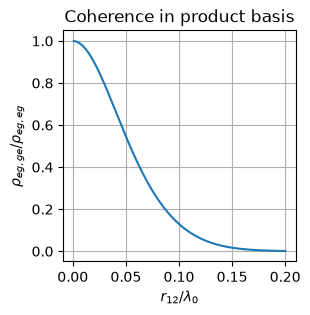

In [119]:
omega0 = 1.0
gamma0 = 0.1
temperature = 1.0
theta = np.pi/4

x = []
y = []
for k in range(1,201):
    omega12 = 0*omega0
    r12=k/1000
    gamma12 = Gamma12(r12,theta)*gamma0
    H = system_hamiltonian(omega0,omega12)
#    c_ops = collapse_operators(omega0,gamma0,gamma12,temperature)
    D = dissipator(omega0,gamma0,gamma12,temperature)
    L = liouvillian(H)+D
    psi0=tensor(basis(2,0),basis(2,0))
    result=mesolve(L,psi0,times)
    rho_ss = result.states[-1]
    x.append(r12)
    y.append(rho_ss[2,1].real/rho_ss[1,1].real)
 
plt.figure(figsize=(3,3))
plt.title("Coherence in product basis")
plt.plot(x,y)
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel(r"$\rho_{eg,ge}/\rho_{eg,eg}$")
plt.grid(True)
plt.show()

To get a better idea, we compare a distance range where significant coherence is possible with the wave length. In the following plot, the first emtter is placed at $r_{12}=0$.  A cosine wave with the wavelength $\lambda_{0}$ begins at the first emitter. If the second is placed with in the red region, 

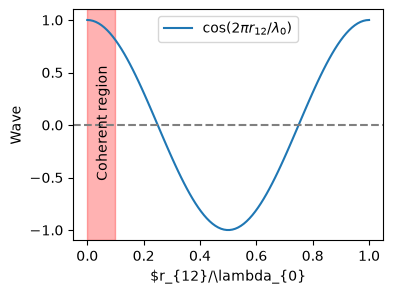

In [141]:
x=np.linspace(0,1,100)
y=np.cos(2*np.pi*x)

plt.figure(figsize=(4,3))
plt.plot(x,y,label=r"$\cos(2\pi r_{12}/\lambda_{0})$")
plt.axhline(y=0,color='grey',ls='--')
plt.axvspan(0, 0.1, color='red', alpha=0.3)
plt.text(0.03, -0.5, "Coherent region", rotation="vertical", fontsize=10, color="k")
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel("Wave")
plt.legend(loc=9)